# 40_plot_from_3d_variables.ipynb — Overview

This notebook extracts 3D WRF fields (e.g., temperature, wind, moisture) and projects them onto 2D horizontal maps at specified **pressure** or **geometric height** levels. It also maps vertically integrated diagnostics such as column water vapor and moisture fluxes. All vertical interpolation, derived metrics, and coordinate handling use [`wrf-python`](https://wrf-python.readthedocs.io/en/latest/) utilities.

## Structure
- **Setup:** configure domain metadata, file paths, analysis time, target pressure/height levels, and plotting options.
- **Load:** discover matching `wrfout_*` files and expose them as a `wrfin` sequence for `wrf-python` utilities.
- **Derive:** interpolate 3D variables to the requested levels, compute divergence/vorticity, moisture fluxes, and column-integrated quantities.
- **Plot:** render scalar maps with optional wind/moisture vectors for each diagnostic.

## Usage
1. Edit the user settings in the first code cell (domain, file pattern, levels, target time).
2. Ensure the requested `wrfout` files exist under `sample_data/Run_WRF/<domain>/<setting>/`.
3. Run cells top-to-bottom. Add `plt.savefig(...)` calls where you need exports.
4. Adjust `map_extent` or vector thinning (`vector_skip`) if the map becomes cluttered.

## Notes
- Required packages: `wrf-python`, `netCDF4`, `numpy`, `xarray`, `matplotlib`, `cartopy`.
- Divergence and vorticity are reported in ×10⁵ s⁻¹ by default.
- Column moisture fluxes integrate specific humidity times wind divided by gravity, approximating integrated vapor transport (IVT).
- Example data paths in this repo point to `sample_data/Run_WRF/Bangkok/test/` but feel free to adapt.


Instructions: Update the user settings below to reflect your domain, file paths, and desired pressure/height levels before executing the cell.

In [13]:
from pathlib import Path
from datetime import datetime
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import Dataset
from wrf import (
    ALL_TIMES,
    getvar,
    interplevel,
    latlon_coords,
    to_np,
)

# ----------------------
# USER SETTINGS
# ----------------------
domain_name = "Bangkok"
domain_id = "d03"
setting = "test"
data_dir = Path("/mnt/work/yuasa/simulation/Run_WRF") / domain_name / setting
wrf_pattern = f"wrfout_{domain_id}_*"

# Target analysis time (UTC). If None, the first snapshot is used.
target_time = "2025-01-04 06:00:00"

# Levels to extract
target_pressure_hpa = [850, 700, 500]
target_height_msl = [500, 1500, 3000]

# Diagnostics to plot for each surface type
pressure_diagnostics = [
    "temperature",
    "theta",
    "wind",
    "specific_humidity",
    "geopotential_height",
    "moisture_flux",
]
height_diagnostics = [
    "temperature",
    "theta",
    "wind",
    "specific_humidity",
    "moisture_flux",
]

# Map styling
map_extent = None  # e.g., [99.5, 101.5, 13.0, 15.0]
vector_skip = 4  # thin quiver/barb density
cbar_kwargs = {"shrink": 0.9}


Instructions: Run the next cell to locate WRF files, open them with `netCDF4.Dataset`, and resolve the target time index.

In [14]:
def find_wrf_files(base_dir: Path, pattern: str):
    files = sorted(base_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matched: {base_dir / pattern}")
    return files


def open_wrfin(files):
    return [Dataset(str(path)) for path in files]


def resolve_time_index(wrfin, target_time_str):
    times_da = getvar(wrfin, "times", timeidx=ALL_TIMES)
    times = np.array([np.datetime64(str(t)) for t in to_np(times_da)])

    if target_time_str:
        target = np.datetime64(target_time_str.replace(" ", "T"))
        idx = int(np.argmin(np.abs(times - target)))
    else:
        idx = 0
        target = times[idx]

    return idx, times[idx]


wrf_files = find_wrf_files(data_dir, wrf_pattern)
wrfin = open_wrfin(wrf_files)
timeidx, analysis_time = resolve_time_index(wrfin, target_time)
print(f"Loaded {len(wrfin)} file(s). Using time index {timeidx} at {analysis_time} UTC.")

Loaded 8 file(s). Using time index 63 at 2025-01-04T06:00:00.000000000 UTC.


Instructions: The following functions preload 3D fields and derive pressure/height level diagnostics. Run them before generating plots.

In [35]:
def preload_3d_fields(wrfin, timeidx):
    fields = {
        "pressure": getvar(wrfin, "pressure", timeidx=timeidx),
        "temperature": getvar(wrfin, "tk", timeidx=timeidx),
        "theta": getvar(wrfin, "theta", timeidx=timeidx),
        "qvapor": getvar(wrfin, "QVAPOR", timeidx=timeidx),
        "height": getvar(wrfin, "z", timeidx=timeidx, units="m"),
        "terrain": getvar(wrfin, "ter", timeidx=timeidx, units="m"),
        "u": getvar(wrfin, "ua", timeidx=timeidx, units="m s-1"),
        "v": getvar(wrfin, "va", timeidx=timeidx, units="m s-1"),
    }
    # dx = float(getvar(wrfin, "dx"))
    # dy = float(getvar(wrfin, "dy"))
    return fields


def compute_pressure_diagnostics(fields, level_hpa):
    p = fields["pressure"]
    results = {
        "temperature": interplevel(fields["temperature"], p, level_hpa),
        "theta": interplevel(fields["theta"], p, level_hpa),
        "specific_humidity": interplevel(fields["qvapor"], p, level_hpa) * 1000.0,
        "wind_u": interplevel(fields["u"], p, level_hpa),
        "wind_v": interplevel(fields["v"], p, level_hpa),
        "geopotential_height": interplevel(fields["height"], p, level_hpa),
    }
    results["moisture_flux_u"] = (
        interplevel(fields["qvapor"], p, level_hpa) * results["wind_u"]
    )
    results["moisture_flux_v"] = (
        interplevel(fields["qvapor"], p, level_hpa) * results["wind_v"]
    )
    results["specific_humidity"].attrs["units"] = "g kg^-1"
    results["moisture_flux_u"].attrs["units"] = "kg kg^-1 m s^-1"
    results["moisture_flux_v"].attrs["units"] = "kg kg^-1 m s^-1"
    return results


def compute_height_diagnostics(fields, level_m):
    z = fields["height"]
    results = {
        "temperature": interplevel(fields["temperature"], z, level_m),
        "theta": interplevel(fields["theta"], z, level_m),
        "specific_humidity": interplevel(fields["qvapor"], z, level_m) * 1000.0,
        "wind_u": interplevel(fields["u"], z, level_m),
        "wind_v": interplevel(fields["v"], z, level_m)
    }
    q_level = interplevel(fields["qvapor"], z, level_m)
    results["moisture_flux_u"] = q_level * results["wind_u"]
    results["moisture_flux_v"] = q_level * results["wind_v"]
    results["specific_humidity"].attrs["units"] = "g kg^-1"
    results["moisture_flux_u"].attrs["units"] = "kg kg^-1 m s^-1"
    results["moisture_flux_v"].attrs["units"] = "kg kg^-1 m s^-1"
    return results


def compute_column_diagnostics(wrfin, fields, timeidx):
    pw = getvar(wrfin, "pw", timeidx=timeidx)
    pressure = fields["pressure"]
    qv = fields["qvapor"]
    u = fields["u"]
    v = fields["v"]
    g = 9.81
    q_u = to_np(qv * u)
    q_v = to_np(qv * v)
    p_np = to_np(pressure)
    flux_u = np.trapz(q_u, p_np, axis=0) / g
    flux_v = np.trapz(q_v, p_np, axis=0) / g
    template = qv.isel(bottom_top=0)
    flux_u_da = xr.DataArray(flux_u, dims=template.dims, coords=template.coords)
    flux_v_da = xr.DataArray(flux_v, dims=template.dims, coords=template.coords)
    flux_u_da.attrs["units"] = "kg m^-1 s^-1"
    flux_v_da.attrs["units"] = "kg m^-1 s^-1"
    flux_mag = xr.apply_ufunc(np.hypot, flux_u_da, flux_v_da)
    flux_mag.attrs["units"] = "kg m^-1 s^-1"
    return {"pw": pw, "flux_u": flux_u_da, "flux_v": flux_v_da, "flux_mag": flux_mag}

fields_3d = preload_3d_fields(wrfin, timeidx)
fields_3d["temperature"]

<xarray.DataArray 'temp' (bottom_top: 47, south_north: 99, west_east: 99)> Size: 2MB
array([[[298.64816, 298.73322, 298.7096 , ..., 299.18033, 299.00275,
         298.97327],
        [298.76065, 298.73987, 298.71176, ..., 299.274  , 299.14603,
         299.0327 ],
        [298.77725, 298.38904, 298.27893, ..., 299.33936, 299.21622,
         299.09842],
        ...,
        [297.2227 , 297.38794, 297.53848, ..., 295.55078, 295.69992,
         295.7899 ],
        [297.24033, 297.37598, 297.57718, ..., 295.7672 , 295.93622,
         296.01706],
        [297.17456, 297.36133, 297.54175, ..., 295.90268, 296.03772,
         296.1784 ]],

       [[297.9985 , 298.07928, 298.06082, ..., 298.60986, 298.4273 ,
         298.40286],
        [298.0984 , 298.0944 , 298.05267, ..., 298.6761 , 298.52286,
         298.4599 ],
        [298.11218, 297.92047, 297.81906, ..., 298.71805, 298.57397,
         298.50952],
...
        [197.46199, 197.47296, 197.47833, ..., 198.35817, 198.3652 ,
         198.36642],
        [197.46242, 197.47343, 197.47693, ..., 198.35922, 198.36514,
         198.36603],
        [197.47066, 197.46921, 197.4692 , ..., 198.36069, 198.36646,
         198.37166]],

       [[203.44302, 203.44836, 203.44008, ..., 204.90958, 204.91371,
         204.91785],
        [203.44406, 203.463  , 203.4654 , ..., 204.91864, 204.92038,
         204.92026],
        [203.43108, 203.45996, 203.47368, ..., 204.9271 , 204.92628,
         204.92383],
        ...,
        [201.48376, 201.50461, 201.52257, ..., 203.51788, 203.52197,
         203.52698],
        [201.46777, 201.49371, 201.51141, ..., 203.48483, 203.49081,
         203.49799],
        [201.44794, 201.462  , 201.47618, ..., 203.45004, 203.45818,
         203.46617]]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 39kB 99.59 99.61 ... 101.4 101.4
    XLAT     (south_north, west_east) float32 39kB 12.87 12.87 ... 14.63 14.63
    XTIME    float32 4B 4.68e+03
    Time     datetime64[ns] 8B 2025-01-04T06:00:00
Dimensions without coordinates: bottom_top, south_north, west_east
Attributes:
    FieldType:      104
    MemoryOrder:    XYZ
    description:    temperature
    units:          K
    stagger:        
    coordinates:    XLONG XLAT XTIME
    projection:     Mercator(stand_lon=100.5, moad_cen_lat=13.749992370605469...
    _FillValue:     1e+20
    missing_value:  1e+20

Instructions: Execute the next cell to set up reusable plotting helpers for scalar fields, contours, and vector overlays.

In [36]:
def _get_latlon(field):
    lat, lon = latlon_coords(field)
    return to_np(lat), to_np(lon)


def _setup_map(extent_override):
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={"projection": proj})
    if extent_override:
        ax.set_extent(extent_override, crs=proj)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor="0.5", facecolor="0.9")
    ax.add_feature(cfeature.OCEAN, facecolor="0.8")
    ax.gridlines(draw_labels=True, linewidth=0.3, linestyle=":")
    return fig, ax


def plot_scalar_map(field, title, units, cmap="viridis", levels=None, extent=None,
                    vectors=None, contour=None, vector_skip=vector_skip):
    lats, lons = _get_latlon(field)
    data = to_np(field)

    if extent is None:
        extent = [lons.min(), lons.max(), lats.min(), lats.max()]

    fig, ax = _setup_map(extent)
    mesh = ax.contourf(lons, lats, data, levels=levels, cmap=cmap, extend="both",
                       transform=ccrs.PlateCarree())
    plt.colorbar(mesh, ax=ax, label=units, **cbar_kwargs)

    if contour:
        ax.contour(
            lons,
            lats,
            to_np(contour["field"]),
            levels=contour.get("levels"),
            colors=contour.get("colors", "k"),
            linewidths=contour.get("linewidths", 0.7),
            transform=ccrs.PlateCarree(),
        )

    if vectors:
        u = to_np(vectors["u"])
        v = to_np(vectors["v"])
        ax.quiver(
            lons[::vector_skip, ::vector_skip],
            lats[::vector_skip, ::vector_skip],
            u[::vector_skip, ::vector_skip],
            v[::vector_skip, ::vector_skip],
            transform=ccrs.PlateCarree(),
            color=vectors.get("color", "black"),
            scale=vectors.get("scale", 700),
            width=0.002,
        )

    ax.set_title(title)
    plt.show()


Instructions: Use the next cell to extract diagnostics for your chosen levels and generate example plots. Adjust level lists or diagnostics as needed.

In [37]:
pressure_data

{850: {'temperature': <xarray.DataArray 'temp_interp' (south_north: 99, west_east: 99)> Size: 39kB
  array([[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
  Coordinates:
      XLONG    (south_north, west_east) float32 39kB 99.59 99.61 ... 101.4 101.4
      XLAT     (south_north, west_east) float32 39kB 12.87 12.87 ... 14.63 14.63
      XTIME    float32 4B 4.68e+03
      Time     datetime64[ns] 8B 2025-01-04T06:00:00
      level    float64 8B 8.5e+04
  Dimensions without coordinates: south_north, west_east
  Attributes:
      FieldType:      104
      units:          K
      stagger:        
      coordinates:    XLONG XLAT XTIME
      projection:     Mercator(stand_lon=100.5, moad_cen_lat=13.749992370605469...
      _FillValue:     9.969209

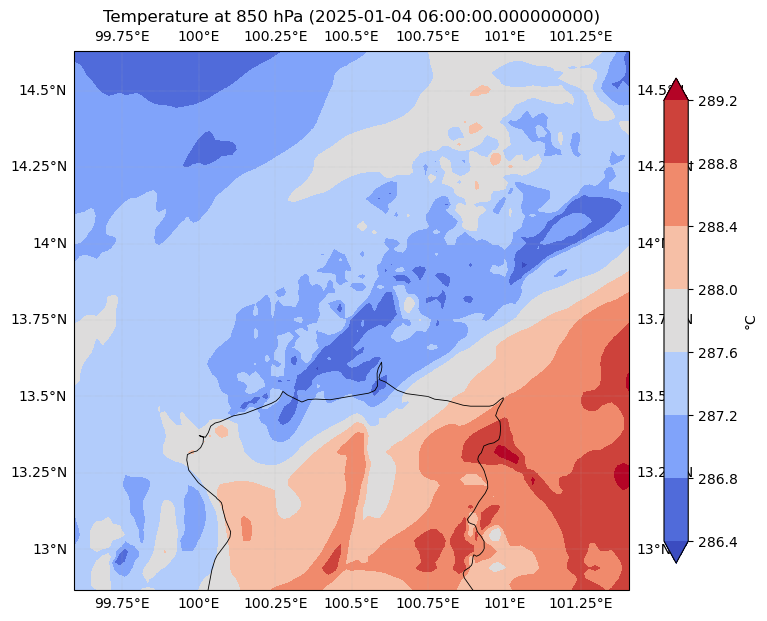

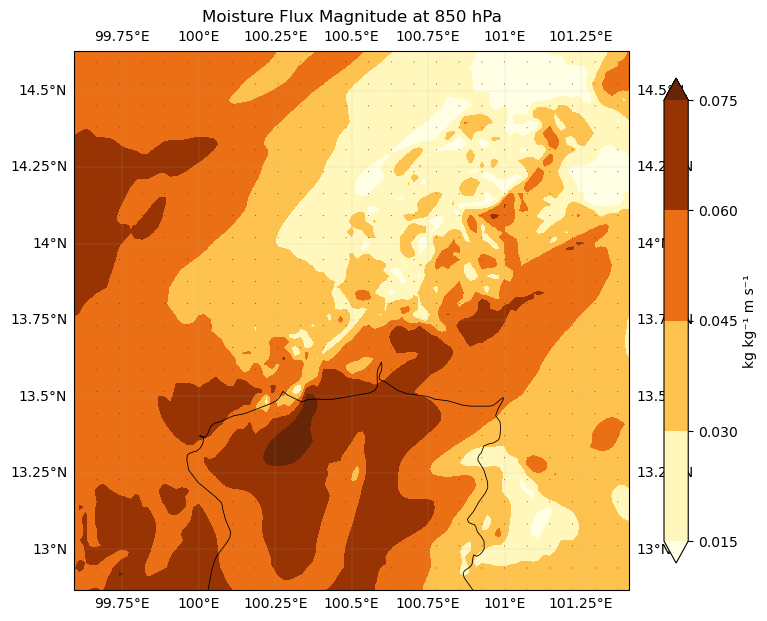

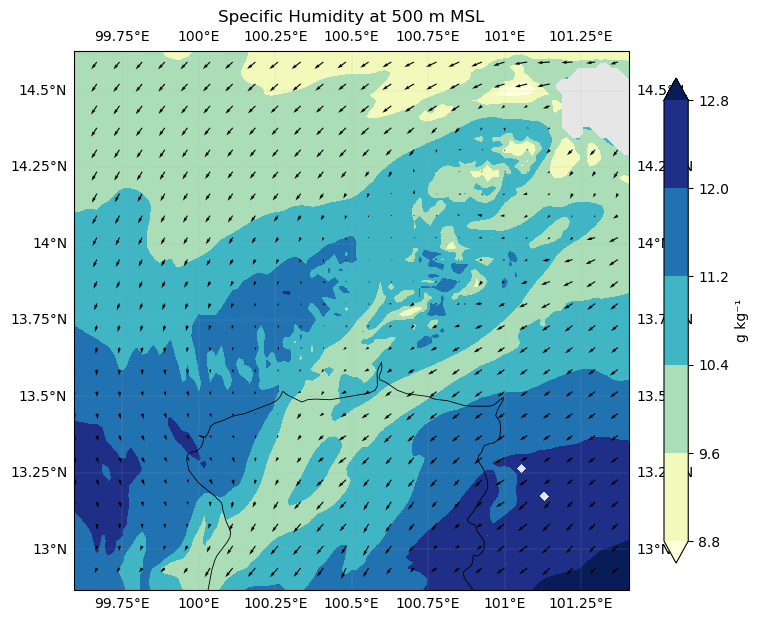

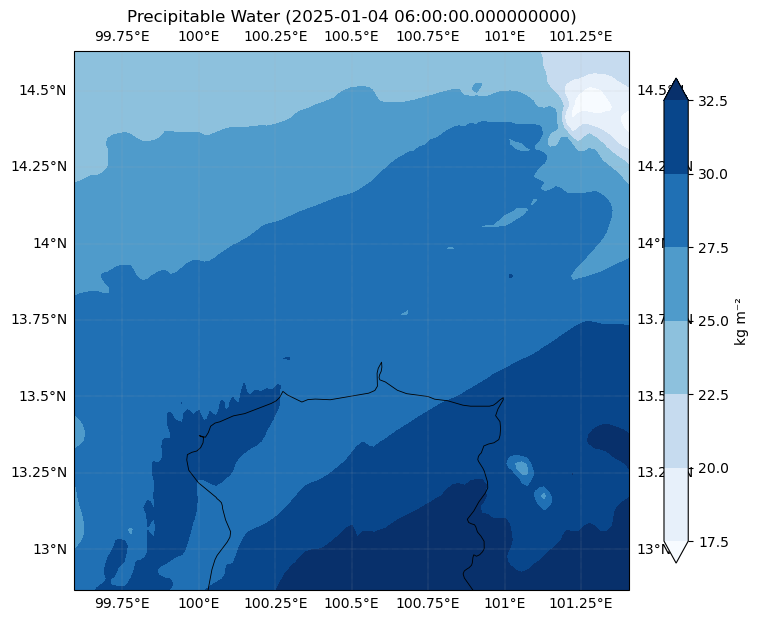

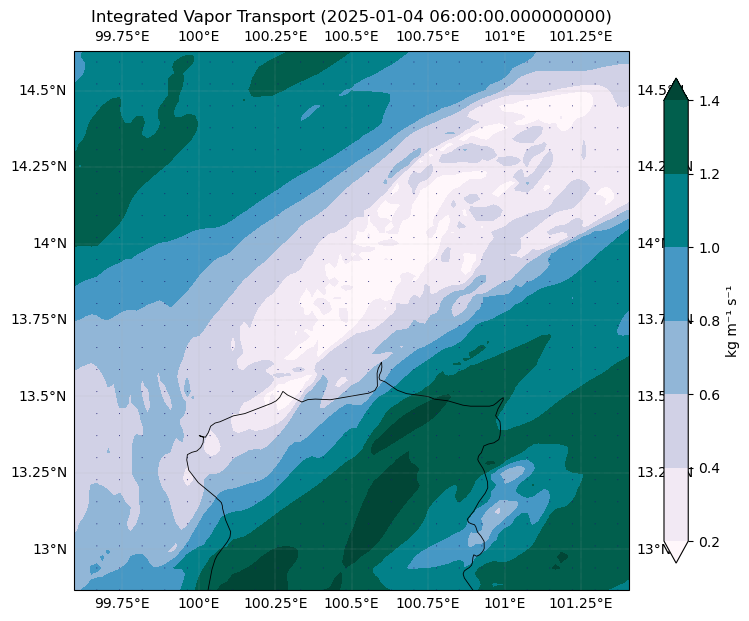

In [38]:
fields_3d = preload_3d_fields(wrfin, timeidx)
pressure_data = {
    lvl: compute_pressure_diagnostics(fields_3d, lvl) for lvl in target_pressure_hpa
}
height_data = {
    lvl: compute_height_diagnostics(fields_3d, lvl) for lvl in target_height_msl
}
column_data = compute_column_diagnostics(wrfin, fields_3d, timeidx)
analysis_label = str(analysis_time).replace("T", " ")

if pressure_data:
    lvl = target_pressure_hpa[0]
    pdata = pressure_data[lvl]
    plot_scalar_map(
        pdata["temperature"],
        f"Temperature at {lvl} hPa ({analysis_label})",
        "°C",
        cmap="coolwarm",
        # extent=map_extent,
        # vectors={"u": pdata["wind_u"], "v": pdata["wind_v"], "scale": 500},
        contour={
            "field": pdata["geopotential_height"],
            "levels": np.arange(0, 9000, 80),
            "colors": "black",
            "linewidths": 0.4,
        },
    )

    div_levels = np.linspace(-8, 8, 17)
    # plot_scalar_map(
    #     pdata["divergence"],
    #     f"Divergence ×10⁵ s⁻¹ at {lvl} hPa",
    #     "×10⁵ s⁻¹",
    #     cmap="RdBu_r",
    #     levels=div_levels,
    #     extent=map_extent,
    # )

    qv_mag = xr.apply_ufunc(np.hypot, pdata["moisture_flux_u"], pdata["moisture_flux_v"])
    qv_mag.attrs["units"] = "kg kg^-1 m s^-1"
    plot_scalar_map(
        qv_mag,
        f"Moisture Flux Magnitude at {lvl} hPa",
        "kg kg⁻¹ m s⁻¹",
        cmap="YlOrBr",
        extent=map_extent,
        vectors={"u": pdata["moisture_flux_u"], "v": pdata["moisture_flux_v"], "color": "firebrick", "scale": 900},
    )

if height_data:
    lvl = target_height_msl[0]
    hdata = height_data[lvl]
    plot_scalar_map(
        hdata["specific_humidity"],
        f"Specific Humidity at {lvl} m MSL",
        "g kg⁻¹",
        cmap="YlGnBu",
        extent=map_extent,
        vectors={"u": hdata["wind_u"], "v": hdata["wind_v"], "scale": 500},
    )

plot_scalar_map(
    column_data["pw"],
    f"Precipitable Water ({analysis_label})",
    "kg m⁻²",
    cmap="Blues",
    extent=map_extent,
)

plot_scalar_map(
    column_data["flux_mag"],
    f"Integrated Vapor Transport ({analysis_label})",
    "kg m⁻¹ s⁻¹",
    cmap="PuBuGn",
    extent=map_extent,
    vectors={"u": column_data["flux_u"], "v": column_data["flux_v"], "color": "midnightblue", "scale": 1200},
)
